# SSF Tuning Analysis
This notebook analyzes the hyperparameter tuning results for the Self-Supervised Feedback (SSF) module in Prompt-UNet.
The tuning compares different strategies and thresholds across two buffer sizes: 4 and 6.

We evaluate:
- The effect of buffer size on volumetric Dice score.
- The performance of different SSF strategies (Relative SSIM, Mask Dice, Confidence Drop).
- The impact on inference time.
- The per dataset mean dice analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

In [16]:
# Load the benchmarking data
df = pd.read_csv('ssf_tuning_results_buffer_4.csv')
# df = pd.read_csv('ssf_tuning_results_buffer_6.csv')

df['buffer_size'] = 4

df.head()

,dataset,pid,run_idx,strategy,vol_dice,time_s,buffer_size
0,nako_combined,nako_head_2,0,none,0.424396,1.825126,4
1,nako_combined,nako_head_2,0,RelSSIM(0.10),0.405286,4.386149,4
2,nako_combined,nako_head_2,0,RelSSIM(0.20),0.405286,1.129186,4
3,nako_combined,nako_head_2,0,RelSSIM(0.30),0.421127,2.321892,4
4,nako_combined,nako_head_2,0,RelSSIM(0.40),0.424779,0.929792,4


In [17]:
mean_dice = df.groupby('strategy')['vol_dice'].mean().sort_values(ascending=False).reset_index()
print(mean_dice)

            strategy  vol_dice
0      RelSSIM(0.40)  0.514509
1      RelSSIM(0.30)  0.507870
2   Confidence(0.10)  0.499882
3   Confidence(0.20)  0.485570
4     MaskDice(0.70)  0.484662
5   Confidence(0.05)  0.481781
6     MaskDice(0.60)  0.480770
7     MaskDice(0.50)  0.478409
8     MaskDice(0.40)  0.473913
9     MaskDice(0.20)  0.472658
10    MaskDice(0.30)  0.471714
11  Confidence(0.30)  0.466715
12     RelSSIM(0.20)  0.465691
13  Confidence(0.40)  0.459888
14              none  0.458788
15     RelSSIM(0.10)  0.420862


## Performance Analysis: Volumetric Dice Score
First, let's examine the overall performance of each strategy across all datasets, split by the buffer size.


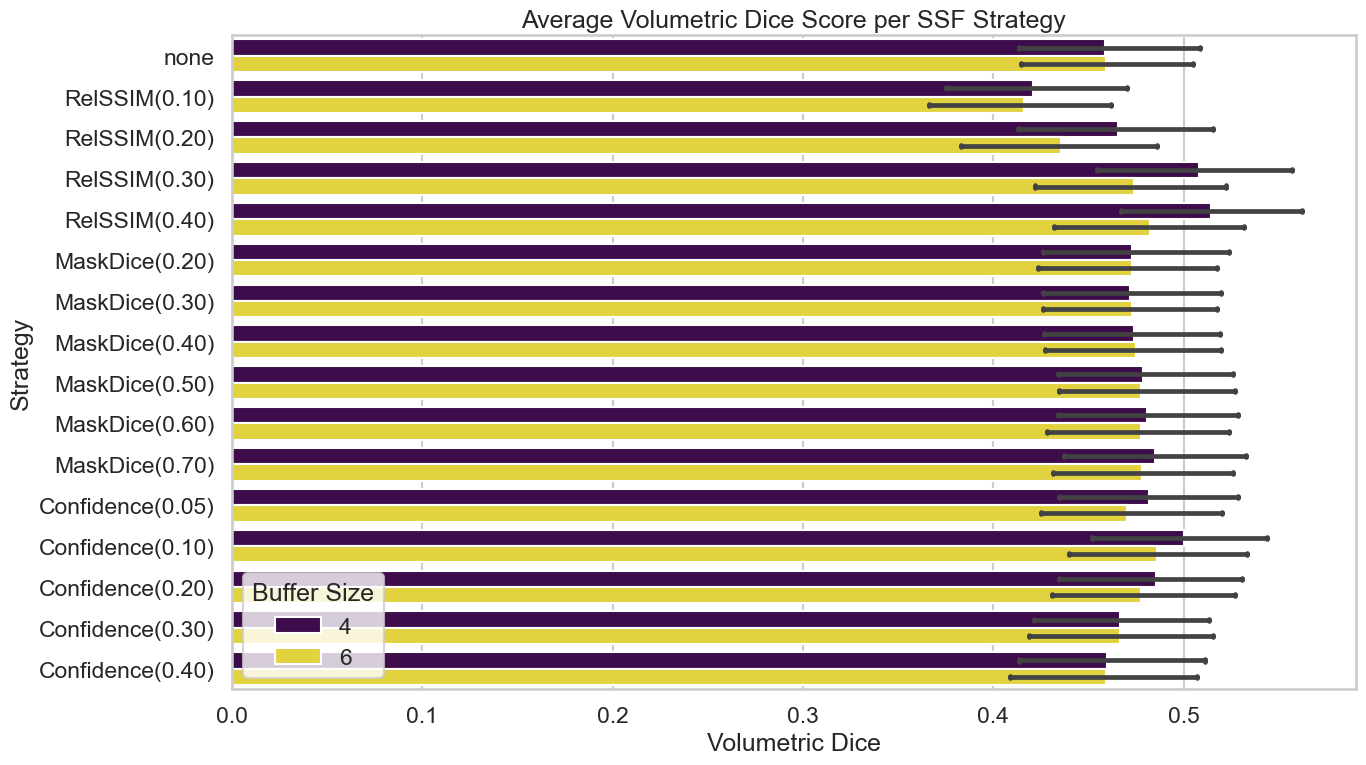

In [3]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df, 
    x='vol_dice', 
    y='strategy', 
    hue='buffer_size',
    errorbar='ci',
    capsize=.1,
    palette='viridis'
)
plt.title('Average Volumetric Dice Score per SSF Strategy')
plt.xlabel('Volumetric Dice')
plt.ylabel('Strategy')
plt.legend(title='Buffer Size', loc='lower left')
plt.tight_layout()
plt.show()

## Per-Dataset Mean Dice Analysis
To evaluate whether SSF strategies are robust across anatomies, we break down the Volumetric Dice score per dataset.
We specifically visualize the best configuration (`Buffer Size 4`) for each strategy across the different datasets.


strategy,Confidence(0.05),Confidence(0.10),Confidence(0.20),Confidence(0.30),Confidence(0.40),MaskDice(0.20),MaskDice(0.30),MaskDice(0.40),MaskDice(0.50),MaskDice(0.60),MaskDice(0.70),RelSSIM(0.10),RelSSIM(0.20),RelSSIM(0.30),RelSSIM(0.40),none
dataset,,,,,,,,,,,,,,,,
brats_gli,0.342333,0.364795,0.376862,0.378571,0.385132,0.385084,0.385524,0.385264,0.396472,0.385324,0.366452,0.324559,0.337257,0.355838,0.379824,0.385132
msd_combined,0.534973,0.570340,0.554097,0.534840,0.509376,0.516385,0.517121,0.517341,0.522748,0.517820,0.527830,0.480953,0.541346,0.567936,0.571458,0.505928
nako_combined,0.429307,0.446414,0.429182,0.401207,0.397394,0.410237,0.406987,0.412702,0.407486,0.408341,0.414447,0.351708,0.363921,0.395651,0.429152,0.398796
total_seg_combined,0.577026,0.577168,0.555980,0.540922,0.541518,0.566351,0.566494,0.566627,0.581424,0.600086,0.605922,0.512653,0.606907,0.692148,0.652937,0.538465


C:\Users\Paul\AppData\Local\Temp\ipykernel_19904\3495479583.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


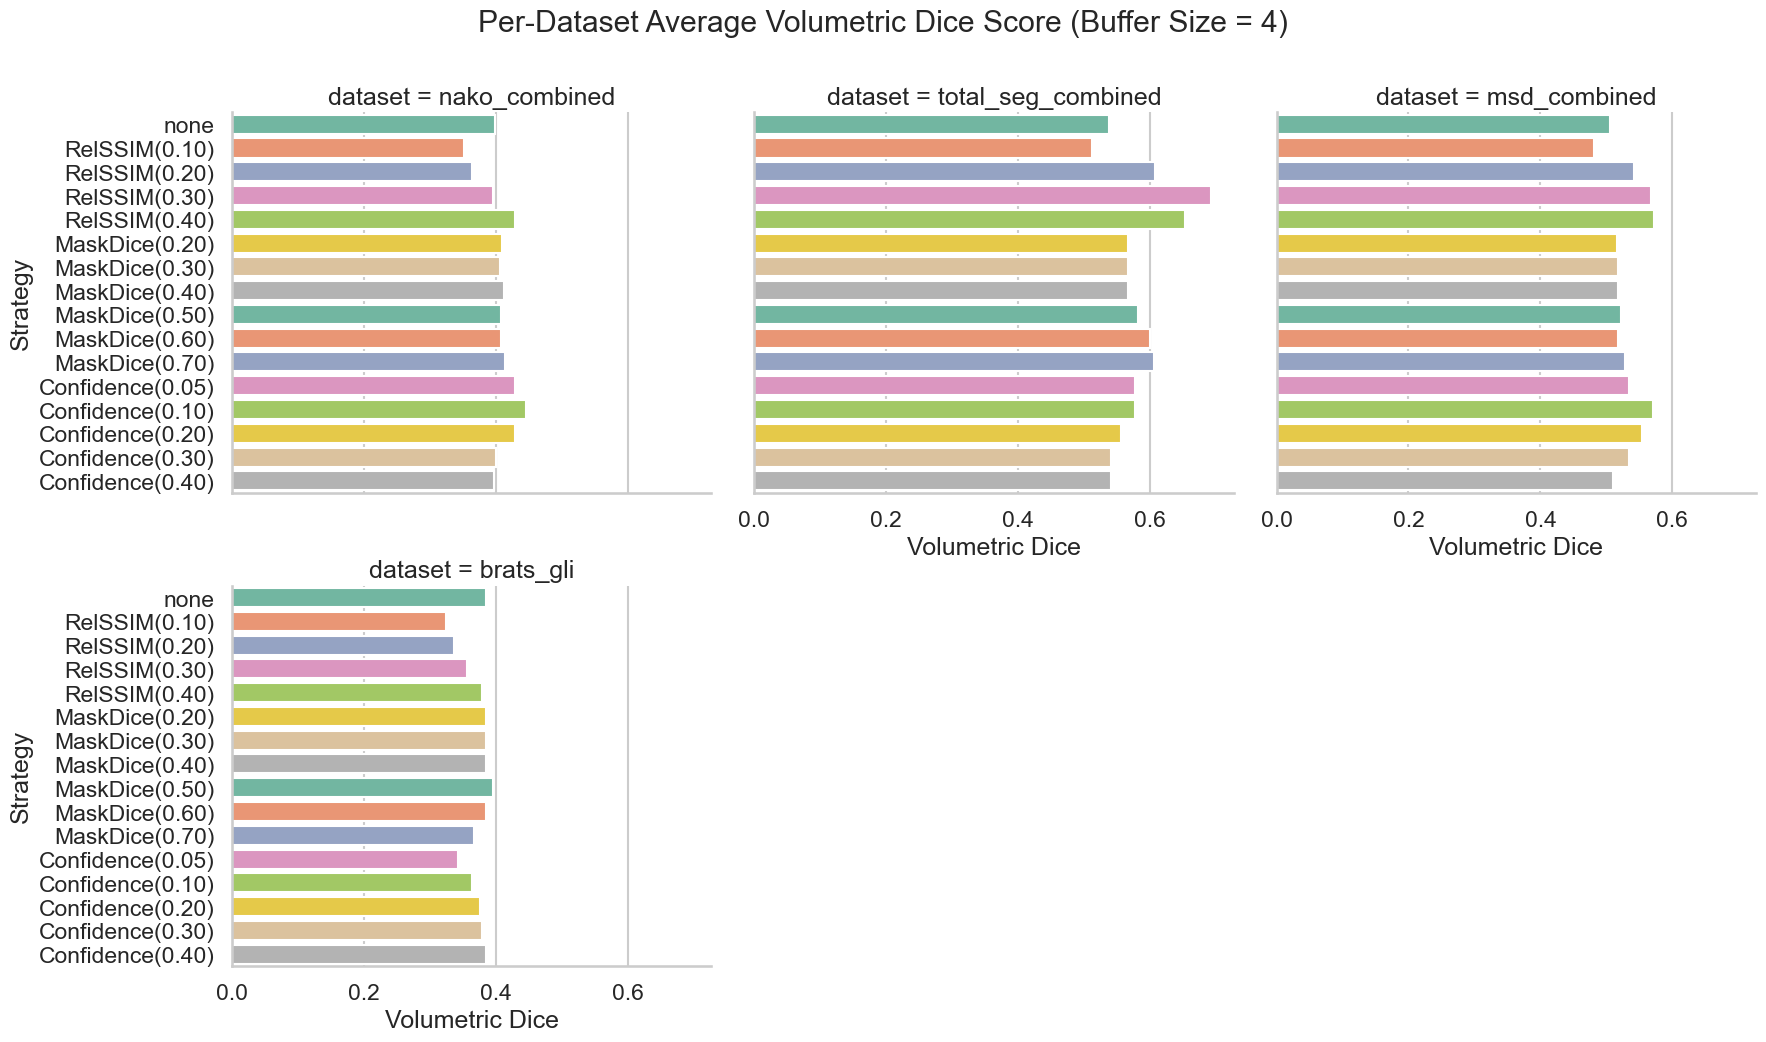

In [4]:
# Filter to just buffer size 4
df_buf4 = df[df['buffer_size'] == 4]

# Pivot table for exact numbers grouped by dataset and strategy
pivot = df_buf4.groupby(['dataset', 'strategy'])['vol_dice'].mean().unstack()
display(pivot)

# Barplot comparison per dataset
g = sns.catplot(
    data=df_buf4,
    kind='bar',
    x='vol_dice',
    y='strategy',
    col='dataset',
    col_wrap=3,
    errorbar=None,
    palette='Set2',
    height=5,
    aspect=1.2
)
g.fig.suptitle('Per-Dataset Average Volumetric Dice Score (Buffer Size = 4)', y=1.05)
g.set_axis_labels('Volumetric Dice', 'Strategy')
plt.show()

## Inference Time Analysis
Self-Supervised Feedback adds computational overhead. Let's look at how much time each strategy takes.


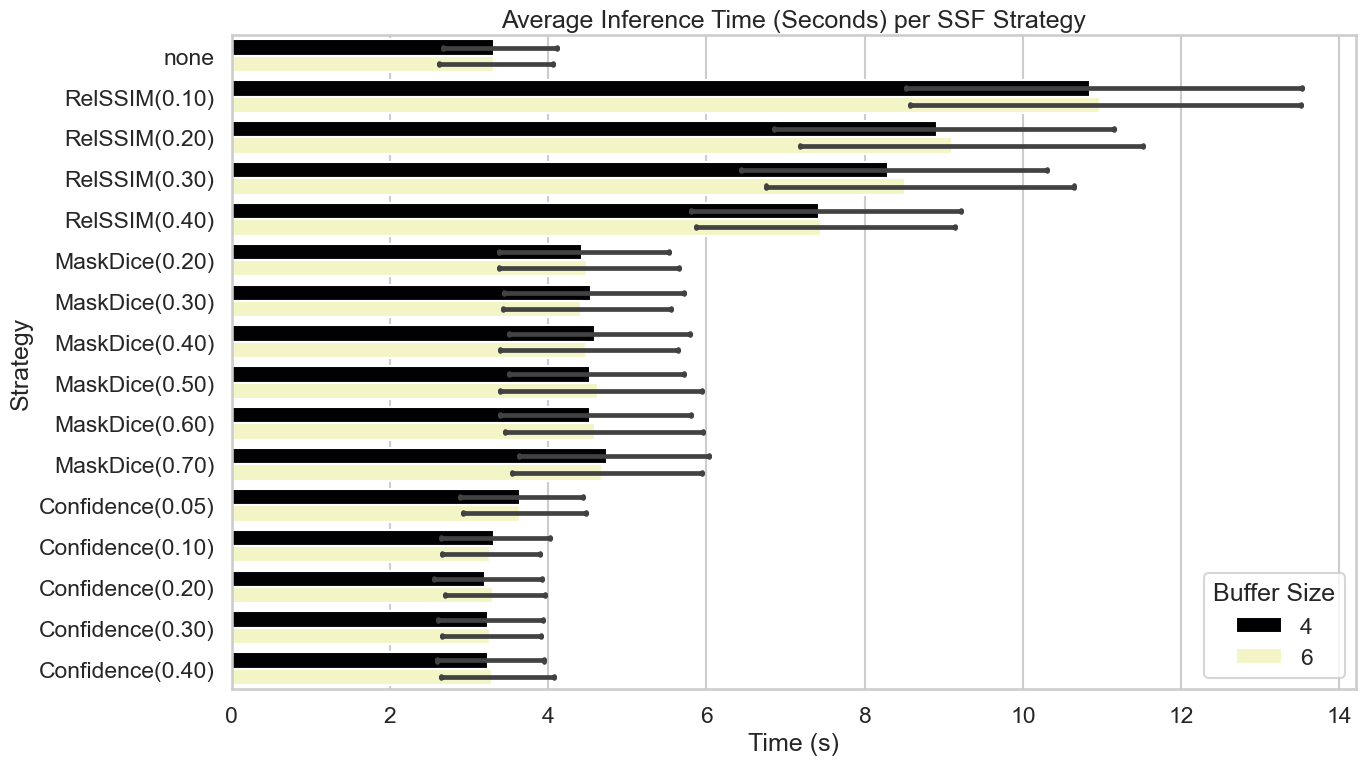

In [5]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df, 
    x='time_s', 
    y='strategy', 
    hue='buffer_size',
    errorbar='ci',
    capsize=.1,
    palette='magma'
)
plt.title('Average Inference Time (Seconds) per SSF Strategy')
plt.xlabel('Time (s)')
plt.ylabel('Strategy')
plt.legend(title='Buffer Size', loc='lower right')
plt.tight_layout()
plt.show()

## Conclusion
Based on both the overall performance and per dataset metrics, **Buffer Size 4 with `RelSSIM(0.40)`** generally yields the best tradeoff between performance and robustness across varied datasets.

Below are the explicit statistics for this top performer against the baseline (`none`).


In [6]:
baseline = df[(df['strategy'] == 'none') & (df['buffer_size'] == 4)]
best = df[(df['strategy'] == 'RelSSIM(0.40)') & (df['buffer_size'] == 4)]

baseline_dice = baseline['vol_dice'].mean()
best_dice = best['vol_dice'].mean()

print(f"Overall Baseline (None) Average Dice: {baseline_dice:.4f}")
print(f"Overall Best Strategy (RelSSIM 0.40, Buffer 4) Average Dice: {best_dice:.4f}")
print(f"Overall Improvement: {best_dice - baseline_dice:+.4f}")

print("\nPer Dataset Improvement:")
for ds in df_buf4['dataset'].unique():
    baseline_ds = baseline[baseline['dataset'] == ds]['vol_dice'].mean()
    best_ds = best[best['dataset'] == ds]['vol_dice'].mean()
    print(f"Dataset: {ds} | Baseline: {baseline_ds:.4f} | Best: {best_ds:.4f} | Diff: {best_ds - baseline_ds:+.4f}")

Overall Baseline (None) Average Dice: 0.4588
Overall Best Strategy (RelSSIM 0.40, Buffer 4) Average Dice: 0.5145
Overall Improvement: +0.0557

Per Dataset Improvement:
Dataset: nako_combined | Baseline: 0.3988 | Best: 0.4292 | Diff: +0.0304
Dataset: total_seg_combined | Baseline: 0.5385 | Best: 0.6529 | Diff: +0.1145
Dataset: msd_combined | Baseline: 0.5059 | Best: 0.5715 | Diff: +0.0655
Dataset: brats_gli | Baseline: 0.3851 | Best: 0.3798 | Diff: -0.0053
